[colab에서 실행하기](https://colab.research.google.com/github/science-odysseia/AILearning/blob/main/AI기초.ipynb)

Colab에서 실행하는 경우 아래 코드를 반드시 실행시켜 주세요.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def auto_tick_step(vmin, vmax):
    span = abs(vmax - vmin)
    if span <= 2: return 0.2
    if span <= 10: return 1
    return 2

def geogebra_style(func, x_range=(-5, 5), y_range=(-0.1, 1.1), x_step=None, y_step=None):
    x = np.linspace(x_range[0], x_range[1], 1000)
    y = func(x)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x, y, linewidth=4, color='#1E88E5', zorder=3) # 그래프가 격자 위로 오도록 zorder 설정

    # 축 설정 (원점 기준)
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')

    # ===== 눈금 간격 결정 (직접 입력값 vs 자동 계산) =====
    final_x_step = x_step if x_step else auto_tick_step(*x_range)
    final_y_step = y_step if y_step else auto_tick_step(*y_range)

    # 주 눈금 (숫자 표시)
    xticks = np.arange(x_range[0], x_range[1] + final_x_step, final_x_step)
    yticks = np.arange(y_range[0], y_range[1] + final_y_step, final_y_step)
    
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # 보조 눈금 (격자용, 주 눈금의 절반)
    ax.set_xticks(np.arange(x_range[0], x_range[1], final_x_step/2), minor=True)
    ax.set_yticks(np.arange(y_range[0], y_range[1], final_y_step/2), minor=True)

    # 격자 디자인
    ax.grid(which='major', linewidth=1.2, color='#cfd8dc', alpha=0.8)
    ax.grid(which='minor', linewidth=0.5, color='#eceff1', alpha=0.5)
    ax.set_axisbelow(True) # 격자를 그래프 뒤로

    # 비율 및 범위
    ax.set_aspect('auto')
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()

import os

if "AILearning" not in os.getcwd():
    !git clone https://github.com/science-odysseia/AILearning.git
    os.chdir("/content/AILearning")


![AI_Diagram](imgs/AI_Diagram.png)

## 학습 패러다임(학습 방법)

### 1. 지도 학습

입력과 정답(레이블)이 쌍으로 주어진 데이터로 학습. 

마치 선생님이 문제와 답을 함께 알려주며 가르치는 것과 같다.

예시 : 

- 분류: 이메일이 스팸인지 아닌지 판단

- 회귀: 주택 가격 예측, 매출 예측


### 2. 비지도학습

정답 없이 데이터의 숨겨진 패턴을 스스로 발견

예시 :

- 군집화 (Clustering): 고객을 구매 패턴에 따라 그룹화

- 차원축소 (Dimensionality Reduction): 복잡한 데이터를 2D로 시각화

### 3. 자기지도학습

데이터 자체에서 자동으로 레이블을 만들어 학습

대표 모델

BERT (언어), ViT (비전), GPT (언어)

### 4. 강화학습

시행착오를 통해 보상을 최대화하는 행동을 학습

예시 : 

로봇 청소기 학습
- 먼지 제거 성공 → +1점
- 장애물 충돌 → -5점
- 배터리 부족 전 충전소 도착 → +10점
→ 수천 번 시행착오 후 최적 청소 경로 학습


## 머신러닝 기초

입력 데이터를 모델이 넣어 예측값을 얻는 과정

![model1.png](imgs/machinelearning1.png)

### 선형 모델

가장 단순한 예측 모델

가장 단순하지만, 모든 복잡한 신경망의 기초 단위가 되는 중요한 개념이다.

![linear_regression](imgs/linear_regression1.jpeg)

$Y = W X + B$

$Y$ : 계산된 예측값, 
$W$ : 가중치(기울기로 생각하면 된다.), 
$X$ : 입력값, 
$B$ : 편향, 

여기서 $W$와 $B$는 `파라미터`라고 불린다.
### 손실(Loss)

계산된 예측값과 실제 정답과의 차이를 `오차`라고 부른다.

그리고 여러 개의 예측값들에 대하여 여러 오차값들이 나올 것이다.

이를 통틀어 손실을 계산하는 함수를 `손실함수` 라고 부른다.

우리의 목표는 이 `손실함수의 값`을 `최소화`하는 것이 되겠다.

### 역전파

위에서 언급한 손실함수의 기울기 값을 계산하는 과정이다.

자세한 과정은 아래에서 설명할 것이다.

### 학습

학습에 반영시키는 과정이다.

이를 종합하면 학습과정은 아래 그림과 같이 정리할 수 있다.

![model2](imgs/machinelearning2.png)



## 경사하강법 (Gradient Descent)

우리의 목표는 손실을 최소화하는 것이고, 이는 곧 손실함수의 최솟값을 찾아가는 과정이 되겠다.

그렇다면 어떻게 찾아갈 것인가?

예시로 손실함수의 형태가 아래와 같다고 해보자.

![gradient_descent](imgs/gradient_descent1.png)

검정색 점을 화살표 방향으로 내려보내면 최소점을 향해 갈 수 있을 것이다.

접선의 기울기는 그 점에서 y값(여기선 손실이 되겠다.)이 얼마나 빠르게 증가하는지를 나타내므로

이 값에 비례하게 반대 방향으로 점을 이동시키면 최소점을 향해 갈 수 있을 것이다.

이를 식으로 나타내면 다음과 같다.

$$ W_{new} = W - lr \cdot \nabla L $$

$L$ 은 손실(Loss)로, $\nabla L$은 그냥 그 점의 접선의 기울기로 생각하면 된다.

$lr$은 학습률로, 기울기에 어느정도로 비례하여 내려갈 지를 정하는 상수값이다. 우리가 설정해 줘야 하는 값이다.

검정색 점이 이동할 보폭 정도로 생각하면 된다.

보폭이 클수록 왔다갔다 크게크게 이동할 것이고, 보폭이 작을수록 섬세하게 조금씩 이동한다.

이 학습률이 과도하게 크면 최소지점 근처에서 방황할 수 있으며, 너무 작으면 학습이 느려질 수 있다.

<br>

위에서 언급한 `역전파` 계산 과정이 $\nabla L$을 계산하는 과정,

`학습`과정이 이를 이용해 $W$를 갱신하는 과정이다.

# 학습률 조정 알고리즘

위에서 나온 $lr$을 조절하는 알고리즘이다.

`epoch`은 학습 횟수이다.

1. StepLR : 계단식 감소

![StepLR](imgs/StepLR.png)

- 장점 : 간단하고 직관적
- 단점 : 급격한 변화로 불안정

2. CosineAnnealingLR : 부드러운 곡선

![CosineAnnealingLR](imgs/CosineAnnealingLR.png)

- 장점 : 안정적이고 범용적
- 적용 : 이미지 분류에 효과적

3. OneCycleLR : 최신 기법
![OneCycleLR](imgs/OneCycleLR.png)

- 장점 : 가장 효과적인 최신 기법
- 적용 : 대규모 학습에 최적

# 손실함수(Loss Function)

여러 입력값에는 여러 출력값이 나오고, 그에 해당하는 여러 정답값들이 있을 것이며,

이들과의 차이인 오차를 통틀어 수치화하는 함수를 손실함수라고 한다.

손실함수의 종류에는 다음과 같은 것들이 있다.

- 회귀 : MSE(Mean Square Error), MAE(Mean Absolute Error), Huber Loss
- 이진분류 : BCE(Binary Cross Entropy), BCEWithLogitsLoss
- 다중분류 : CrossEntropy, WeightCrossEntropy

1. MSE(Mean Square Error)

$$
\frac{\Sigma (예측값 - 정답)^2}{N}
$$

예측값과 정답의 차이의 제곱의 평균

가장 널리 사용되고, 모든 지점에서 미분이 가능하며, 큰 오차에 더 큰 패널티를 부여하는 방식이다. 단, 이상치에 민감하다는 단점이 있다.

2. MAE(Mean Absolute Error)

$$
\frac{\Sigma \left|예측값 - 정답\right|}{N}
$$

예측값과 정답의 차이의 절댓값의 평균

MSE에 비해 오차에 덜 민감하며, 직관적인 해석이 가능하지만, 예측값과 정답이 거의 같아지는 지점 근처에서는 미분이 불가하다는 단점이 있다.

이상치가 많은 데이터나, 해석 가능성이 중요한 데이터에 주로 사용한다.

3. Huber Loss

Huber Loss에서는 아래 식을 통해 나온 값들의 평균을 낸다.

$$
L_\delta (e) = \begin{cases} \frac {1}{2}e^2 & \left| e \right| \le \delta \\\\ \delta (\left| e \right| - \frac {1}{2}\delta) & \left| e \right| > \delta \end{cases}
$$

$e = \left| 예측값 - 정답 \right |$, $\delta = 내가 설정한 임계값$

MAE와 MSE의 장점을 합쳐 만든 손실함수로, **"강건함(Robustness)"**과 **"안정성(Stability)"**을 동시에 챙기는 함수이다.

4. BCE(Binary Cross Entropy)

이진분류에서는 정답(레이블)을 0클래스, 1클래스로 변환하여

해당 클래스의 정답이 1일 확률 `p`를 예측값으로 도출하는 방식을 사용한다.

즉, `p`가 0.5 이상이면 정답을 1, 아니면 정답을 0으로 보는 것이다.

$$
L = -[y \log {p} + (1 - y) \log {(1 - p)}]
$$

$$
L = -[ \underbrace{y \cdot \log({p})}_{\text{정답이 1일 때}} + \underbrace{(1 - y) \cdot \log({1 - p})}_{\text{정답이 0일 때}} ]
$$

$y=1$일때, 즉 정답이 1일 때 `p`가 높을수록 오차가 0으로 수렴하고,

`p`가 낮을수록 오차가 기하급수적으로 커진다.

 $y=0$일 때, 즉 정답이 0일 때`p`가 높을수록 오차가 기하급수적으로 커지고,
 
`p`가 낮을수록 오차가 0에 수렴한다.

5. CrossEntropy

이진분류가 정답이 1일 확률을 도출했다면

다중분류는 각 정답 클래스별 확률을 도출하여

가장 높은 확률을 정답으로 내놓는다.

여기서는 각 클래스별 확률 분포를 만들기 위해 `Softmax`라는 함수를 이용한다.

$$
Softmax = \frac {e^{x_i}}{\Sigma e^x}
$$

## 활성화 함수(Activation Function)

선형 모델만으로 세상 모든 데이터를 분석 및 분류할 수 있으면 좋겠지만

세상은 그렇지 않고 훨씬 더 복잡한 데이터들이 많다.

하지만 우리가 위에서 배운 선형 모델만을 사용한다면 아래 수식들처럼 선형 수식을 영원히 탈출할 수 없다.

$$ y_1 = w_1 \cdot x + b_1 $$

$$ y_2 = w_2 \cdot y_1 + b_2 = w_2 \cdot (w_1 \cdot x + b_1) + b_1 = w_3 \cdot x + b_3 $$

$$ y_3 = w_4 \cdot y_2 + b_4 = w_4 \cdot (w_1 \cdot x + b_1) + b_4 = w_5 \cdot x + b_5 $$

$$ \vdots $$

가령 아래 예시 이미지를 살펴보자.

![example1](imgs/linear_regression2.png)

위 그림같은 경우 선형 모델만으로는 예측 모델을 만들기 어렵다.

그래서 아래 그림처럼 비선형성을 추가하여 비선형적 예측 모델을 만들어야 한다.

![example2](imgs/linear_regression3.png)

여기서 사용되는 비선형성 함수를 `활성화함수`라고 한다.

활성화함수의 대표적인 예시는 아래와 같다.

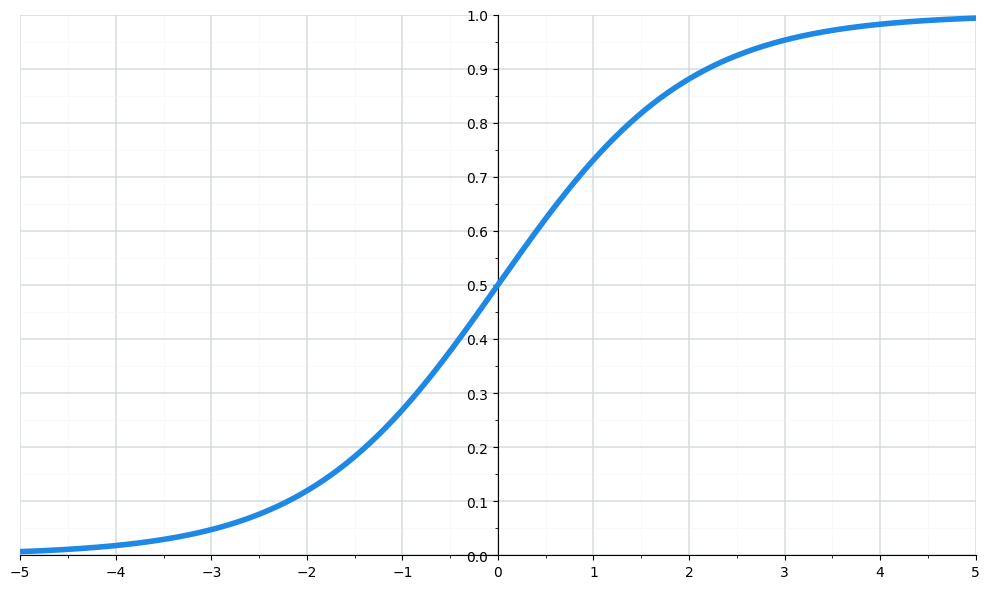

In [19]:
geogebra_style(lambda x : 1/(1 + np.exp(-x)), (-5, 5), (0, 1), 1, 0.1)

1. Sigmoid

$$ y = \frac{1}{1+e^{-x}} $$

가장 대표적으로 쓰이는 활성화함수.

특징 : 

그래프에서 보다시피, 입력값 x에 어떤 값을 넣더라도 0 - 1 사이의 확률값으로 변환 가능하게 해주는 함수이다.

다만 접선의 기울기의 최댓값이 $\frac{1}{4}$ 이고, 입력값이 극으로 갈수록 기울기가 0에 수렴하기 때문에

여러 층을 거치면 기울기가 0에 수렴해지게 되어 (chain rule 에 의해 $\frac{1}{4}$ 이하의 기울기들이 계속 곱해져 0에 수렴해간다.)

이후 역전파 및 학습 과정에서 학습이 더디게 되는 `기울기 소실 문제`가 발생한다.

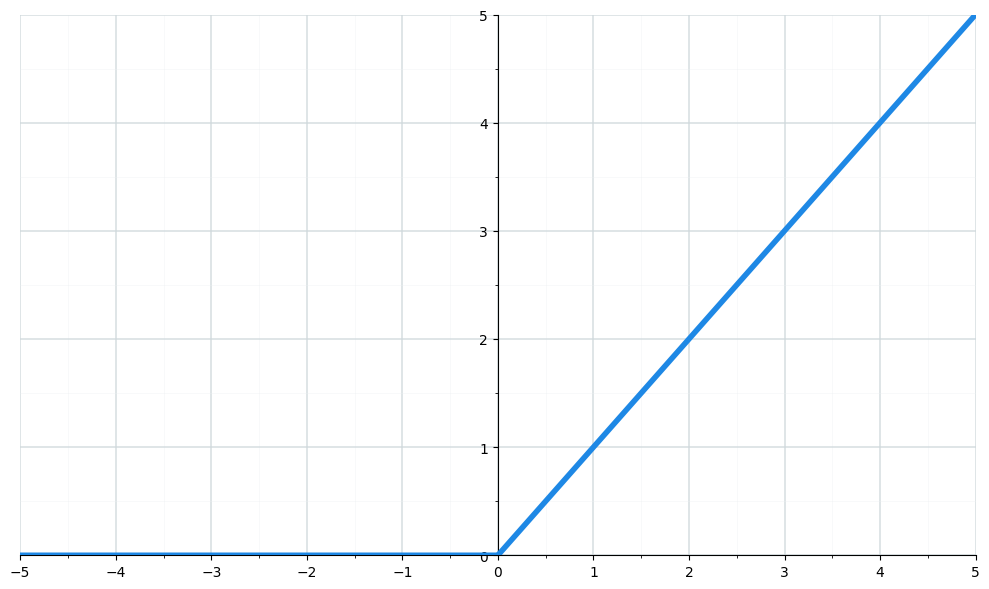

In [20]:
geogebra_style(lambda x : np.maximum(x, 0), (-5, 5), (0, 5), 1, 1)

2. ReLU
$$
y = \begin{cases} x & x > 0 \\\\ 0 & x \le 0 \end{cases} 
$$

가장 대표적으로 쓰이는 또 하나의 활성화함수.

Sigmoid의 `기울기 소실 문제`를 해결하기 위해 나온 함수이다.

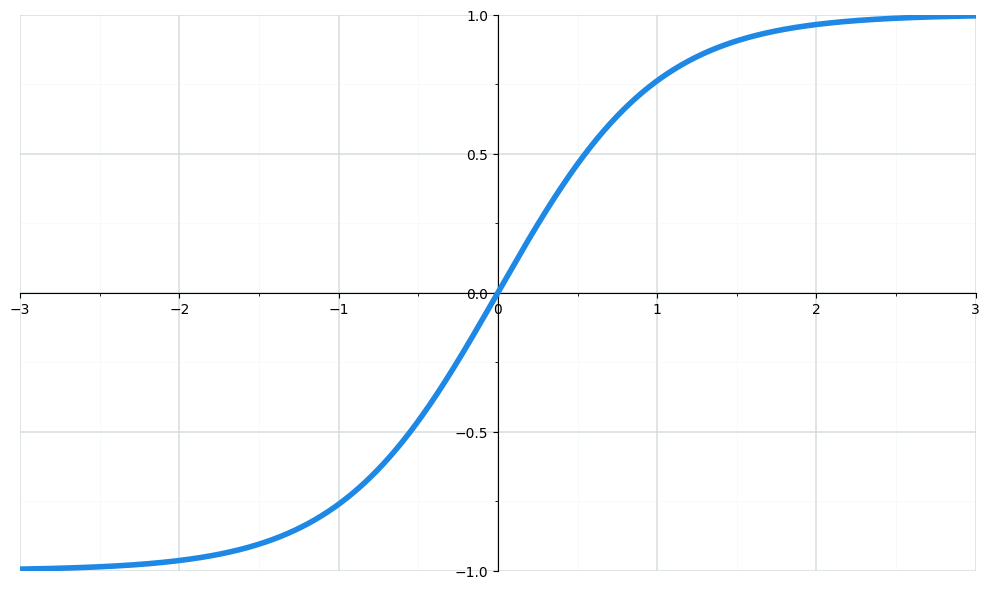

In [21]:
geogebra_style(lambda x : np.tanh(x), (-3, 3), (-1, 1), 1, 0.5)

3. tanh

$$ y = \tanh (x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}} $$

이외에도 다양한 함수들이 있지만 이정도(사실 tanh도 잘 안쓰는 편이긴 하다.)까지가 대표적으로 사용하는 활성화함수의 예이다.

# 순전파 및 역전파

역전파는 앞에서 기울기를 계산하는 과정이라고 했다.

순전파는 예측값을 계산하는 과정이다.

즉, 순전파는 앞으로 진행하는 과정, 역전파는 뒤로 되돌아가는 과정이라고 생각하면 된다. 

앞에서 배운 활성화함수를 적용한 순전파 및 역전파 학습 과정을 그림으로 나타내면 아래와 같다.

![forward](imgs/machinelearning3.png)

![backward](imgs/machinelearning4.png)

여기서 나오는 은닉층은 가중치층, 즉 $W$값들로 이루어진 층으로 생각하면 된다.

# 가중치 초기화

학습을 시작하려면 먼저 모델이 있어야 한다.

그리고 시작 모델의 가중치와 편향값($W$, $B$)를 정해주어야 연산을 할 수 있다.

이것 또한 학습의 시작점으로, 이 값을 잘 설정해 주어야 학습에 문제가 생기지 않는다.

만약 시작 모델의 

1. 모든 가중치를 0으로 시작한다면

- 모든 뉴런이 똑같이 학습되는 대칭성 문제 발생
- 3개의 뉴런이 있어도 1개의 뉴런처럼 작동

2. 가중치를 너무 **크게** 설정한다면

- 활성화 값이 폭발하고 활성화 함수가 포화됨
- **gradient 소실**로 학습 멈춤

3. 가중치를 너무 **작게** 설정한다면

- 깊은 층을 통과할 수록 **신호**가 **0**으로 수렴하게 되어 정보전달이 안됨

가중치 초기화 방법은 대표적으로 아래 2가지가 있다.

1. Xavier 초기화

$$
\sqrt {\frac {2}{n_{in} + n_{out}}}
$$

입력과 출력의 분산을 균형 있게 유지

특징

- 출력 분포 안정
- 깊은 네트워크에서도 비교적 안정

사용 : 

``` python
nn.init.xavier_normal_(layer.weight)
```

2. He 초기화
- ReLU에서 죽는 뉴런 문제 해결(ReLU는 음수 다 0으로 만들어버림 ⇒ 분산 줄어듦 ⇒ 해결 필요)

$$
\sqrt {\frac {2}{n_{in}}}
$$

ReLU는 절반(음수)이 사라지기 때문에 $n_{in}$만 고려하여 분산을 더 크게 잡음

특징

1. ReLU에 최적화
2. 더 큰 분산 유지

사용 : 

``` python
nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
```

\#\# `nn.Linear()` 만들면 자동 초기화가 적용됨

# 과적합

![Overfitting1](imgs/Overfitting1.jpeg)

모델이 훈련 데이터에 거의 안맞아도 정확도가 떨어져서 문제이지만,

모델이 훈련 데이터에 너무 잘맞아도 과적합 문제가 발생한다.

위 그림에서도 보이듯이, 예측 모델이 전혀 이상한 방향으로 가고 있다.

예측 모델이 이상하게 나와도, 정확도가 조금이라도 높은 게 더 좋은거 아닌가 할 수도 있다.

과적합의 진짜 문제는

**주어지지 않았던 완전히 새로운 입력 데이터에 대해 극도로 민감하게 반응하여 이상한 결과값을 도출할 수 있다**는 점이다.